In [1]:
import matplotlib.pyplot as plt
import joblib as jlb

from collections import Counter
from pyclustering.cluster.clarans import clarans
from Customer_dataset import data
processed_data=data

In [2]:
print(processed_data.tail(1))

     Age  Income_Level  Gender_Male
999   38         54931            0


In [3]:
#data to list vi claran chi chap nhan list
x = processed_data.values.tolist()
print(x[0])

[23, 70541, 0]


In [4]:
#xay dung model clarans
k = 5
n_local=5
max_nei=4
Clarans_model = clarans(x, number_clusters=k, numlocal=n_local, maxneighbor=max_nei)
Clarans_model.process()

In [5]:
#lấy cluster và medoids
clusters = Clarans_model.get_clusters()
medoids = Clarans_model.get_medoids()

print("Clusters:", clusters)
print("Medoids:", medoids)

Clusters: [[27, 33, 43, 44, 48, 50, 57, 63, 64, 67, 73, 78, 83, 95, 98, 102, 106, 108, 109, 111, 112, 126, 127, 128, 130, 132, 133, 136, 138, 144, 147, 148, 149, 159, 161, 164, 166, 169, 170, 173, 179, 183, 184, 187, 194, 195, 214, 217, 218, 222, 232, 244, 247, 250, 252, 256, 267, 273, 280, 284, 287, 295, 302, 306, 309, 314, 315, 317, 322, 330, 335, 338, 343, 344, 345, 350, 355, 358, 368, 371, 376, 377, 382, 383, 395, 397, 403, 412, 415, 416, 419, 426, 427, 434, 437, 438, 444, 445, 450, 453, 460, 461, 476, 477, 479, 482, 485, 486, 495, 498, 507, 513, 514, 519, 521, 528, 530, 533, 536, 550, 556, 557, 558, 568, 569, 575, 578, 580, 584, 591, 592, 593, 603, 606, 608, 612, 615, 625, 634, 637, 644, 646, 647, 654, 655, 657, 662, 669, 674, 675, 680, 687, 689, 690, 691, 692, 701, 704, 709, 712, 713, 714, 722, 733, 735, 736, 737, 738, 740, 743, 752, 753, 754, 757, 759, 762, 765, 768, 769, 777, 779, 781, 790, 792, 801, 804, 807, 808, 813, 817, 820, 823, 829, 832, 835, 846, 847, 850, 856, 858, 867

In [6]:
#gắn nhãn cluster đã có vào df
labels = [0] * len(data)

for cluster_id, cluster in enumerate(clusters):
    for index in cluster:
        labels[index] = cluster_id

processed_data['cluster'] = labels
print(processed_data.head(1))
print('\nKích thước clusters:', Counter(labels))
print('\n2 clusters lớn nhất:', Counter(labels).most_common(2))

   Age  Income_Level  Gender_Male  cluster
0   23         70541            0        2

Kích thước clusters: Counter({2: 284, 4: 235, 0: 227, 1: 201, 3: 53})

2 clusters lớn nhất: [(2, 284), (4, 235)]


In [7]:
#luu model
jlb.dump(Clarans_model,'../customer_clustering/Output/clarans.mdl')

['../customer_clustering/Output/clarans.mdl']

In [8]:
#load model
Loaded_Clarans_model = jlb.load('../customer_clustering/Output/clarans.mdl')

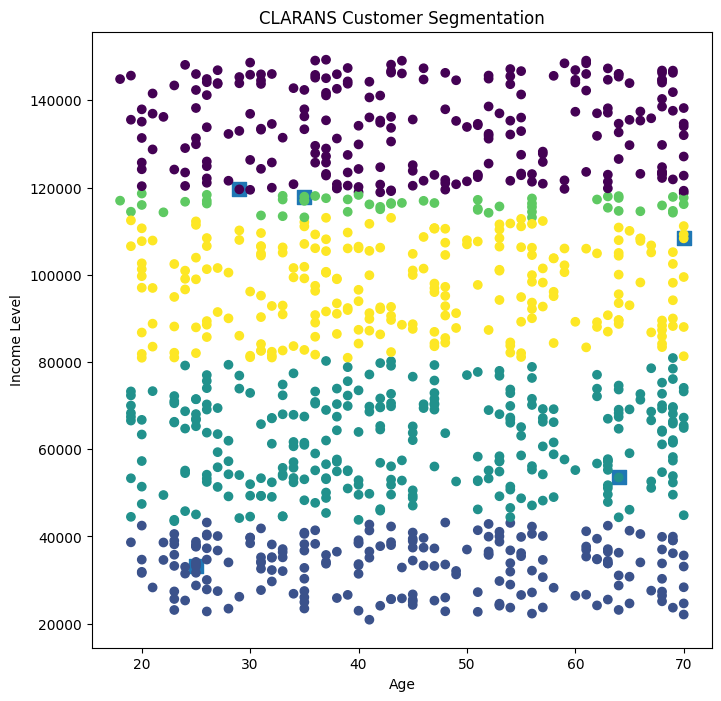

In [9]:
#hien thi model
medoid_points = processed_data.iloc[medoids]

plt.figure(figsize=(8,8))

plt.scatter(medoid_points['Age'],
            medoid_points['Income_Level'],
            marker='s',
            s=100
            )

plt.scatter(processed_data['Age'],
            processed_data['Income_Level'],
            c=processed_data['cluster'])

plt.xlabel("Age")
plt.ylabel("Income Level")
plt.title("CLARANS Customer Segmentation")

plt.show()